In [29]:
import numpy as np 
import numpy.linalg as lin
import cv2 
import matplotlib.pyplot as plt

In [30]:
def rot3D(alpha, beta, gamma):
    ca = np.cos(alpha)
    sa = np.sin(alpha)
    cb = np.cos(beta)
    sb = np.sin(beta)
    cg = np.cos(gamma)
    sg = np.sin(gamma)
    
    Rx = np.array([[1,   0,  0 ], [0,  ca, -sa], [ 0,  sa, ca]])
    Ry = np.array([[cb,  0,  sb], [0,  1,   0 ], [-sb, 0,  cb]])
    Rz = np.array([[cg, -sg, 0 ], [sg, cg,  0 ], [ 0,  0,  1 ]])
    
    return Rx@Ry@Rz
    

In [31]:
X = np.array([[-7.5, -2.5, -2.5, -7.5,  2.5,  7.5,  7.5,  2.5],
               [ 7.5,  7.5,  2.5,  2.5, -2.5, -2.5, -7.5, -7.5],
               [ 0,    0,    0,    0,    0,    0,    0,    0  ],
               [ 1,    1,    1,    1,    1,    1,    1,    1  ]])

X = X / 100 #Convertimos las unidades a metros

#Definimos Parámetros intrinsecos: K

fx = fy = 950
Cx = 1980 // 2
Cy = 1080 // 2

K = np.array([[fx, 0, Cx], [0, fy, Cy], [0, 0, 1]])
iK = np.array([[1/fx, 0, -Cx / fx], [0, 1/fy, -Cy / fy], [0, 0, 1]])

T = np.array([0.3, -0.2, 5], ndmin = 2).T

alpha =  15 * np.pi / 180
beta  = -20 * np.pi / 180
gamma =  30 * np.pi / 180

R = rot3D(alpha, beta, gamma)

In [32]:
print("Parametros Extrinsecos\n")
print("K = \n", K, "\n")
print("iK = \n", iK, "\n")
print("copmutrf inv(K) = \n", lin.inv(K), "\n\n")

print("Parámetros extrínsecos")

print(T)
print(R)
print('\n')
print(np.cross(R[:,0], R[:,1]).T)
print('\n')
print(np.cross(R[:,1], R[:,2]).T)
print('\n')
print(np.cross(R[:,2], R[:,0]).T)

Parametros Extrinsecos

K = 
 [[950   0 990]
 [  0 950 540]
 [  0   0   1]] 

iK = 
 [[ 0.00105263  0.         -1.04210526]
 [ 0.          0.00105263 -0.56842105]
 [ 0.          0.          1.        ]] 

copmutrf inv(K) = 
 [[ 0.00105263  0.         -1.04210526]
 [ 0.          0.00105263 -0.56842105]
 [ 0.          0.          1.        ]] 


Parámetros extrínsecos
[[ 0.3]
 [-0.2]
 [ 5. ]]
[[ 0.81379768 -0.46984631 -0.34202014]
 [ 0.4063012   0.88077697 -0.24321035]
 [ 0.41551495  0.05896082  0.90767337]]


[-0.34202014 -0.24321035  0.90767337]


[0.81379768 0.4063012  0.41551495]


[-0.46984631  0.88077697  0.05896082]


In [41]:
#Encontramos la proyeccion de las esquinsa en el plano espacial (X) en la imagen (x)

Dummy = np.hstack([np.eye(3), np.zeros((3,1))])
G = np.vstack([np.hstack([R, T]), np.array([0, 0, 0, 1])])

print("K = \n", K, "\n")
print("Dummy = \n", Dummy, "\n")
print("G = \n", G, "\n")
P = K @ Dummy @ G;

print("P = \n", P)

#Encontramos la proyeccion de la esquina en el plano espacial (X) en la imagen(x)

x = P @ X

regs, cols = x.shape
print(x.shape)
for i in range(cols):
    print("x[:, %d].T = " %i, x[:, i], "\n")
    
#Asegurarnos que el tercer renglon de x esta compuesto por unos.
for i in range(cols):
    if x[2, i] != 0:
        x[:, i] /= x[2, i]


K = 
 [[950   0 990]
 [  0 950 540]
 [  0   0   1]] 

Dummy = 
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]] 

G = 
 [[ 0.81379768 -0.46984631 -0.34202014  0.3       ]
 [ 0.4063012   0.88077697 -0.24321035 -0.2       ]
 [ 0.41551495  0.05896082  0.90767337  5.        ]
 [ 0.          0.          0.          1.        ]] 

P = 
 [[ 1.18446760e+03 -3.87982780e+02  5.73677501e+02  5.23500000e+03]
 [ 6.10364208e+02  8.68576963e+02  2.59093791e+02  2.51000000e+03]
 [ 4.15514949e-01  5.89608233e-02  9.07673371e-01  5.00000000e+00]]
(3, 8)
x[:, 0].T =  [-6.55837782e+01  4.44659567e+01  2.32584406e-02] 

x[:, 1].T =  [-6.36039840e+00  7.49841671e+01  4.40341880e-02] 

x[:, 2].T =  [13.03874059 31.55531889  0.04108615] 

x[:, 3].T =  [-4.61846392e+01  1.03710850e+00  2.03103994e-02] 

x[:, 4].T =  [9.16612594e+01 1.86446811e+01 5.89138531e-02] 

x[:, 5].T =  [1.50884639e+02 4.91628915e+01 7.96896006e-02] 

x[:, 6].T =  [1.70283778e+02 5.73404333e+00 7.67415594e-02] 

x[:, 7].T =  [ 1.11060398e

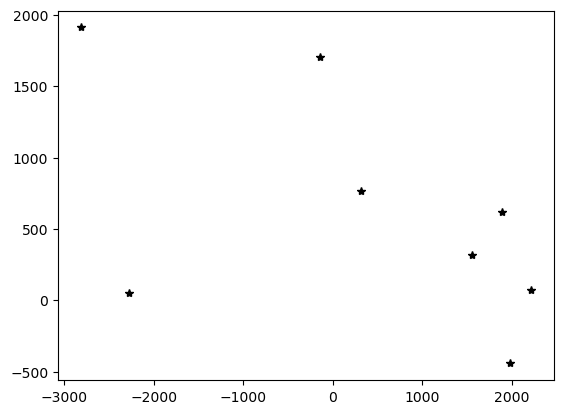

In [40]:
fig, ax = plt.subplots()

ax.plot(x[0, :], x[1, :], '*k')
plt.show()

In [ ]:
#Canonizamos las esquinas qen la imagen

xc = iK @ x
for i in range(cols):
    print("xc[:, %d].T = " %i, xc[:, i], "\n")
    
fig, ax = plt.subplots()

ax.plot(x[0, :], x[1, :], '*k')
plt.show()